# Revisions- Figure 2, 5-7 + Supp Figure 1,2 Analysis and Figure Code

#### Description
Code for analysis and figures in Fig 2, 5-7 and Supplementary Figure 1.
v2- streamlines how figures are made

#### Run Order
- Setup Environment and Imports
- Load & Process Data
- Generate figure outputs for
    - Figure 2: E, F, G, H
    - Figure 5: A
    - Figure 6: A
    - Figure 7: A, E
    - Supplementary Figure 1: B, C, D, E, F, G, H, I, J
    - Supplementary Figure 2: A, B


## Setup


In [79]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [81]:


from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
    
#  Environment & Imports Setup
import numpy as np
import warnings
import pandas as pd
# Fix for seaborn 0.12.1 + pandas 2.0 compatibility
try:
    pd.get_option('mode.use_inf_as_null')
except (pd.errors.OptionError, KeyError):
    pd._config.config._global_config['mode']['use_inf_as_null'] = False
    pd._config.config._registered_options['mode.use_inf_as_null'] = pd._config.config.RegisteredOption(
        key='mode.use_inf_as_null',
        defval=False,
        doc="Deprecated",
        validator=lambda x: None,
        cb=None,
    )

import random
from datetime import datetime
import time
import pingouin as png
import pyarrow as pa
from scipy.stats import chi2_contingency
print(f"Pandas version {pd.__version__} | seaborn_version = {sns.__version__}")
print(f"matplotlib {matplotlib.__version__} | pyarrow: {pa.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) 
from pandas._config.config import RegisteredOption

# random.seed(1)
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

print(f" Here: {root_dir}")
_plot_posthoc_src = os.path.join(root_dir, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)
#custom function import
from config_preprocessing import load_config
from preprocess_data import hyper_param_dict,  get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import save_fig_in_main_fig_dir, save_plot_record_as_csv_txt, make_folder, plot_heatmap_w_kwargs, save_csv_to_analysis_storage
from ax_modifier_functions import set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels, ax_add_stage_names_and_outline_points, add_spaces_linebreak_to_stage_ticks,set_stage_xticks_2_layer
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
from dimension_reduce import *
from sklearn.manifold import TSNE
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])



Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
Pandas version 2.0.3 | seaborn_version = 0.12.1
matplotlib 3.8.4 | pyarrow: 18.1.0
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code


In [82]:

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
data_location = config['data']['data_dir']

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_location}")

##Set/create save and load folder paths 
print(f"Saving results in {results_dir}. Data location is {data_location}")
csv_folder_most_recent = results_dir/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder( csv_folder_most_recent)

Run ID: 20260225_092000, Started: 2026-02-25 09:20:00.588218

Folders used in run ID: 20260225_092000
Results dir: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results
Data dir: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
Saving results in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


#### Import dataset

In [83]:
## LOAD DATASET PARQUET
#set what dataset to use, therefore waht col names are improtant 
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else:   
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
stage_col = 'task_phase_vec'

# load data

trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
# get trial summary info
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()

#get processed dataset 
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)
subject_stage_info_df.sample()

,subject_name,geno_day,task_phase_vec,neuron_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
99,14_2_WT_RS2,WT CLNZ,Early_IA_Error,"[14_2_WT_RS2-8, 14_2_WT_RS2-15, 14_2_WT_RS2-31...",19,142,"[1, 2]",2,"[False, False]"


In [84]:
print(f"Total units {n_total_units.sum()}")
n_total_units

Total units 4776


geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: neuron_ID, dtype: int64

In [85]:
unit_mean_tseries.sample()

,subject_name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial,max_val,max_val_tbin,mean_rate
3011,13_3_HET_RS2,13_3_HET_RS2-62,Het CLNZ,Late_RS,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,False,none,1.0,all_frames,0.0,False,0.0,-3.0s to -2.75s,0.0


#### Create mean activity matrix for visualization

In [86]:
##Define functions to use for activity matrix creation
def get_df_unit_mean_activity_matrix(unit_mean_tseries, 
                                     stage_names,
                                     numeric_col, 
                                     subj_name_col:str = 'subject_name', 
                                     ignore_pre:bool = True):
    all_geno_matrix,  all_geno_IDs= get_unit_mean_phase_activity_matrix( unit_mean_tseries, 
                                                                        use_enrich_unit_only=  False,
                                                                          stage_names =  stage_names,
                                                                          numeric_col =  numeric_col,
                                                                           subj_name_col = subj_name_col,
                                                                            unit_ID_col = unit_ID_col,
                                                                             ignore_pre= ignore_pre)
    mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(
        unit_mean_tseries.groupby(unit_ID_col)['geno_day'].first().to_frame(),left_index = True, right_index = True)
    if np.nanmean(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) == 0)>0:
        mean_AV_matrix = mean_AV_matrix.loc[(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) > 0),:]
    return mean_AV_matrix

## preprocessing and normalization steps
def get_unit_mean_phase_activity_matrix(unit_mean_tseries, 
                                        use_enrich_unit_only,
                                          stage_names,
                                            numeric_col,
                                            subj_name_col = 'subject_name',
                                             unit_ID_col = 'neuron_ID',
                                              ignore_pre:bool= True, ):
    '''#TO- create matrix that's = concatenated vectors of all neuron mean activationni phase (output matrix = # units x # phases)    OUTPUT- '''
    matrix_IDs, stack_matrix,nan_df_list = dict(), dict(),[]
    skip_rec = dict()
    ## if going to skip pre-outcome period, change what counts as numeric col
    if ignore_pre:
        numeric_col = [col for col in numeric_col if '-' not in col]
    for dataset in unit_mean_tseries[subj_name_col].unique():
        matrix_list = []
        dataset_df = unit_mean_tseries.loc[ (unit_mean_tseries[subj_name_col] == dataset),:]
        if len(dataset_df.task_phase_vec.unique()) < len(stage_names):#check that dataset has ALL 6 phases, if not, skip
            skip_rec[dataset] = len(dataset_df.task_phase_vec.unique())
            # continue
        for stage in stage_names:
            phase_mask = (dataset_df.task_phase_vec == stage)
            matrix = dataset_df.loc[phase_mask, numeric_col].values #get phase entries, producing (dataset_neuron) x (time_bin matrix)
            #check if phase is present, if matrix extracted w phase trials is empty, assume mous elacks it
            if matrix.shape[0] == 0:
                matrix = np.tile(np.nan, (len(dataset_df[unit_ID_col].unique()), len(numeric_col)))
            if np.sum(np.isnan(matrix))>0:
                nan_df_list.append( dataset_df.loc[phase_mask, numeric_col])
            matrix_list.append(matrix)
        stack_matrix[dataset] = np.dstack(matrix_list)
        matrix_IDs[dataset] = dataset_df.loc[phase_mask, unit_ID_col].values
    all_geno_matrix = np.concatenate([val for val in stack_matrix.values()], axis = 0)
    all_geno_IDs =  np.concatenate([val for val in matrix_IDs .values()], axis = 0)
    return all_geno_matrix, all_geno_IDs

## extract tseries of interest to create AV matrix
ID_col_to_drop = 'cell' 
AV_matrix = get_df_unit_mean_activity_matrix(unit_mean_tseries, stage_names, numeric_col,subj_name_col = 'subject_name', ignore_pre =True) # other way will not work: # AV_matrix =  get_df_unit_mean_activity_matrix(trial_tseries_df, stage_names, numeric_col)
AV_matrix['max_phase'] =AV_matrix[stage_names].idxmax(axis = 'columns')
max_95th_quantile = round(AV_matrix[stage_names].quantile(q = 0.95).max(),2)
min_5th_quantile = round(AV_matrix[stage_names].quantile(q = 0.05).min(),2)
print(f"5th percentile mean activation: {min_5th_quantile}, 95th percentile: {max_95th_quantile}")
WT_mask = AV_matrix.geno_day == "WT VEH"
AV_matrix['max_phase_val'] =AV_matrix.apply(lambda x: x[x.max_phase], axis = 1)
no_Early_IA_Error = AV_matrix.Early_IA_Error.isna()
has_Early_IA_Error = ~no_Early_IA_Error
AV_matrix.tail()

5th percentile mean activation: 0.0, 95th percentile: 0.21


C:\Users\13car\AppData\Local\Temp\ipykernel_66440\135111578.py:14: RuntimeWarning: Mean of empty slice
  mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(


,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,geno_day,max_phase,max_phase_val
9_3_HET_RS3-95,0.000000,0.026667,0.000000,0.0,0.000000,0.0,Het postCLNZ,Early_IA_Error,0.026667
9_3_HET_RS3-96,0.000000,0.177500,0.093333,0.0,0.000000,0.0,Het postCLNZ,Early_IA_Error,0.177500
9_3_HET_RS3-97,0.033333,0.123333,0.000000,0.0,0.000000,0.0,Het postCLNZ,Early_IA_Error,0.123333
9_3_HET_RS3-98,0.040000,0.000000,0.000000,0.0,0.045333,0.0,Het postCLNZ,Late_IA,0.045333
9_3_HET_RS3-99,0.003333,0.000000,0.000000,0.0,0.009333,0.0,Het postCLNZ,Late_IA,0.009333


In [87]:
enrichment_matrix = unit_mean_tseries.groupby(by = unit_ID_col)[['geno_day']+ stage_names].first()
tsne_results= {}
for geno_count, geno in enumerate(geno_order_w_WT_CLNZ):
    geno_AVs = AV_matrix.loc[AV_matrix.geno_day ==geno , stage_names].dropna()
    tsne_results[geno]=return_TSNE_on_stage_AV_w_enrich_labels(geno_AVs, enrichment_matrix, stage_names) # tsne_params = {'n_components': 2, "perplexity": 90, "method":'exact', 'init':'pca'}

## Supplementary Figure 1 plots

#### Supplement Figure 1B- # of cells per subject

C:\Users\13car\AppData\Local\Temp\ipykernel_66440\2933168003.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


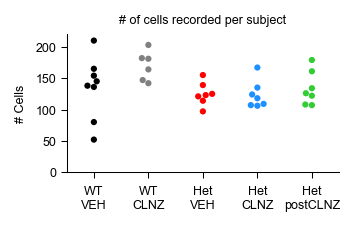

In [88]:
fig, ax = plt.subplots(1,1, figsize=(2.25,1.4), layout = 'constrained')
cell_count =  subject_stage_info_df.groupby([subject_col,'geno_day'])['num_units'].max().reset_index()
sns.swarmplot(data = cell_count,
              x = 'geno_day', y = 'num_units', order = geno_order_w_WT_CLNZ, legend = False, s = 3,**geno_order_w_WT_CLNZ_no_eb)
set_labels(ax, label_dict = dict(title =  f"# of cells recorded per subject", ylim = [0,220],xlabel=None, ylabel= f"# Cells"))
ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
save_fig_in_main_fig_dir(fig,fig_name = "Number of cells per subj by geno-day", folder_key='s_2', filetypes_to_save = ['png','svg'])

In [89]:
print(cell_count.info())
cell_count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   subject_name  35 non-null     object
 1   geno_day      35 non-null     object
 2   num_units     35 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 972.0+ bytes
None


,subject_name,geno_day,num_units
0,10_3_HET_RS1,Het VEH,97
1,10_3_HET_RS2,Het CLNZ,124
2,10_3_HET_RS3,Het postCLNZ,122
3,13_3_HET_RS1,Het VEH,121
4,13_3_HET_RS2,Het CLNZ,106
5,13_3_HET_RS3,Het postCLNZ,126
6,13_4_WT_RS1,WT VEH,165
7,13_4_WT_RS2,WT CLNZ,147
8,13_5_HET_RS1,Het VEH,114
9,13_5_HET_RS2,Het CLNZ,118


#### Supplement Figure 1C- % of frames active on average 

In [90]:
trial_event_counts = trial_tseries_df_norm.copy()
trial_event_counts.loc[:,numeric_col] =  trial_event_counts.loc[:,numeric_col] *hyper_param_dict['window_to_bin']
trial_event_counts.loc[:, 'n_events'] = trial_event_counts[numeric_col].sum(axis = 1)
trial_event_counts.loc[:, 'prop_active_frames'] = 100*trial_event_counts.loc[:, 'n_events']/(hyper_param_dict['window_to_bin']*len(numeric_col))
trial_event_counts.sample()

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial,n_events,prop_active_frames
56546,Late_IA,IA,Correct,14,14_2_WT_RS1-24,post_outcome,14_2_WT_RS1,RS1,24,1,...,10000,1.0,False,none,1.0,all_frames,0.0775,True,31.0,8.611111


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.
Saved 2_s_supp_Proportion frames active per trial_posthoc permutation test_25_Feb_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_Proportion frames active per trial_posthoc_text_25_Feb_2026.txt


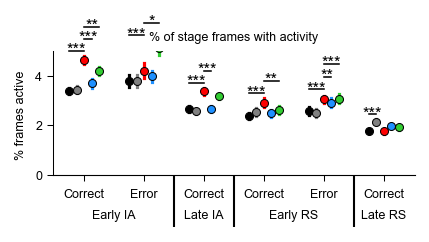

In [91]:
fig,plot_ax = plt.subplots(1,1,figsize = (2.75,1.5), layout = 'constrained')

plot_params =  {'data': trial_event_counts, 
                'errorbar':'se',
                'x':'task_phase_vec',
                'y':'prop_active_frames',
                 'order':stage_chrono_order, 'dodge' :0.5, **geno_color_dict_w_WT_CLNZ}
sc = sns.pointplot(ax = plot_ax, linestyles = 'none', **plot_params, )
ax_title = f"% of stage frames with activity"
set_ax_title_xlabel_ylabel(plot_ax, {'title':ax_title,'ylim': [0, 5], 'ylabel':  '% frames active ', 'xlabel': None, 'legend_false': True})
posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, comparison_list_w_WT_CLNZ, detect_error_bar = True,test_name = 'MWU')
plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
### ANNOTATOR BLOCK END
ax_add_stage_names_and_outline_points(plot_ax)
posthoc_df['plot_name'] = ax_title
fig_name = "supp_"+"Proportion frames active per trial" 
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png','svg'])
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="2_s",fig_name,csv_folder_most_recent, None, csv_suffix="posthoc permutation test",txt_suffix="posthoc_text")

#### Supplementary Figure 1D- plot mean cella activity including WT CLNZ 

Saved 2_s_supp_wtclnz_pointplot_Mean event rate by phase_posthoc MWU_25_Feb_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_supp_wtclnz_pointplot_Mean event rate by phase_posthoc_text_25_Feb_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


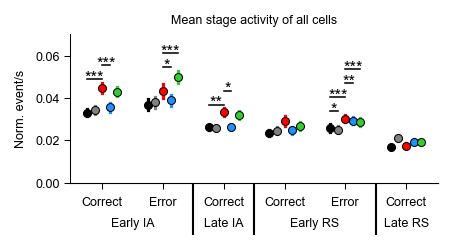

In [92]:
## hue by geno day, rows are task, phases
fig,plot_ax = plt.subplots(1,1,figsize = (3,1.65), layout = 'tight')
plot_params =  {'data': unit_mean_tseries, 'errorbar':'se', 'x':'task_phase_vec', 'y':'mean_rate','orient':'v',
                 'order':phase_list_IA_RS_chrono, 'dodge':0.5, **geno_order_w_WT_CLNZ_no_eb}

sc = sns.pointplot(ax = plot_ax, linestyles = 'none', **plot_params, )
ax_title = f"Mean stage activity of all cells"
set_ax_title_xlabel_ylabel(plot_ax, {'title':ax_title,'ylim': [0,0.07], 'ylabel':  'Norm. event/s', 'xlabel': None, 'legend_false': True})

posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, comparison_list_w_WT_CLNZ,detect_error_bar = True,test_name = 'MWU')
plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:], tight_offset = 0.025)
### ANNOTATOR BLOCK END
ax_add_stage_names_and_outline_points(plot_ax)
posthoc_df['plot_name'] = ax_title
## save figs
fig_name = 'supp'+ f"_wtclnz_pointplot_Mean event rate by phase"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="2_s",fig_name,csv_folder_most_recent, None,
                                csv_suffix="posthoc MWU",txt_suffix="posthoc_text")

save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png'])


#### Supplement Figure 1E- WT VEH mean activation

In [93]:
unit_mean_tseries['max_timebin_index'] = unit_mean_tseries.apply(lambda x: list(numeric_col).index(x.max_val_tbin),axis = 1)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


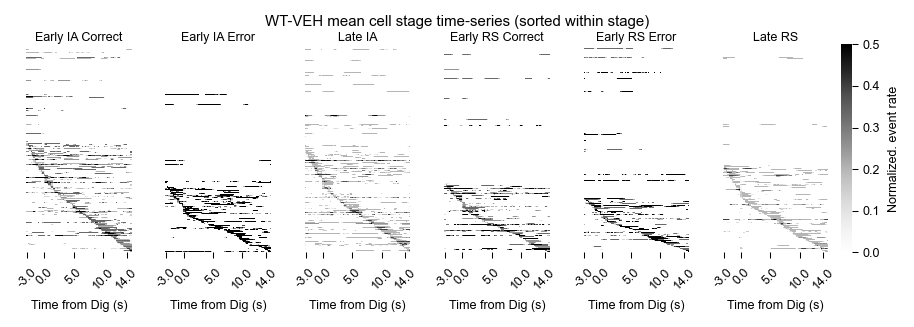

In [94]:
fig, ax_array = plt.subplots(1, len(stage_names), figsize = (6,2), layout = 'constrained', sharex = False, sharey=False,)

tseries_mat = unit_mean_tseries.loc[unit_mean_tseries.geno_day == 'WT VEH',:]
for s, task_stage in enumerate(phase_list_IA_RS_chrono):
    ax_plot = ax_array.flat[s]
    plot_df= tseries_mat.loc[tseries_mat.task_phase_vec == task_stage,:].sort_values(by = 'max_timebin_index', ascending = True).loc[:, numeric_col]
    make_cbar = s in [5]
    sns.heatmap(plot_df, ax = ax_plot,cbar_kws = {'label': f"Normalized. event rate"}, rasterized=True,cbar = make_cbar, vmax = 0.5,cmap = 'Greys',xticklabels=True)
    set_labels(ax_plot, {'title': {'label':task_stage.replace('_', ' '), 'pad':0 },'xlabel': 'Time from Dig (s)'})
    ax_plot.set_yticks([])
    # Extract existing tick labels and positions
    second_tick_to_plot = ['-3.0s','0.0s', '5.0s', '10.0s','14.0s']
    tick_positions = ax_plot.get_xticks()
    tick_labels = [tick.get_text() for tick in ax_plot.get_xticklabels()]
    filtered_ticks = [pos for pos, label in zip(tick_positions, tick_labels) if label.split(" to ")[0] in second_tick_to_plot]# Filter tick positions based on the desired labels
    filtered_labels = [label.split("s to ")[0] for label in tick_labels if label.split(" to ")[0] in second_tick_to_plot]
    # Set the filtered ticks and labels
    ax_plot.set_xticks(filtered_ticks)
    ax_plot.set_xticklabels(filtered_labels, rotation=45, ha='center')
    ax_plot.label_outer()
## save
fig.get_layout_engine().set(w_pad = 0.05, h_pad= 0.01, hspace = 0.00, wspace = 0.00)
figure_title = f"WT-VEH mean cell stage time-series (sorted within stage)"
fig.suptitle(figure_title)
## save fig
fig_name = figure_title
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=2, filetypes_to_save = ['png','svg'])

#### Supplementary Figure 1F- neural stage-activation matrix with WT CLNZ include 

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


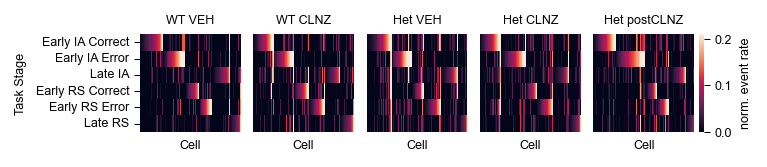

In [95]:
#plot unit heatmap for ALL GENOS
fig_mean_activity, axes = plt.subplots(1,5,figsize = (5,1), layout = 'constrained')
activity_type =  f"norm. event rate"
heatmap_clabel = activity_type

for count, geno in enumerate(geno_order_w_WT_CLNZ):
    plot_mask = (AV_matrix.geno_day == geno) & has_Early_IA_Error
    plot_data = AV_matrix.sort_values(by = ['max_phase','max_phase_val'],ascending = True).loc[plot_mask, stage_chrono_order].T
    plot_heatmap_w_kwargs(data =plot_data.rename(index = {p:p.replace('_', ' ') for p in plot_data.index}), ax =axes.flat[count],
                          kwarg_dict = {
                              'vmin': min_5th_quantile, 'vmax':max_95th_quantile, 'cbar_kws': {'label': heatmap_clabel},
                              'cbar': {True: True, False: False}[count == len(geno_order_w_WT_CLNZ)-1], 'yticklabels': True, 'xticklabels':False},
                          label_dict = {'xlabel': f"Cell", 'ylabel': {False:"Task Stage", True: None}[count > 0], 'title': geno})#plot heatmap
    axes.flat[count].set_yticks({True:[], False: axes.flat[count].get_yticks()}[count > 0])
#save figs
fig_prefix = "supp_" #for sorting in folder
fig_name = 'one_row_cell stage-activity sorted heatmap'
fig_mean_activity.get_axes()
save_fig_in_main_fig_dir(fig_mean_activity, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png'])

#### Get enrichment stats

In [96]:
unique_ID_enrichment_df = unit_mean_tseries.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich = unique_ID_enrichment_df.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = '% enriched')
geno_mean_enrich.head()

#get long df where each row = 1 unique CELL ID and the # of stage's its enriched in
cell_num_stage_enriched_df_long = unique_ID_enrichment_df[stage_names].sum(axis = 1).sort_values().reset_index().rename(columns = {0: 'num_enrich'})
geno_cell_n_enrich_df_wide = cell_num_stage_enriched_df_long.pivot_table(columns = 'num_enrich', index =  'geno_day', aggfunc = 'count').fillna(0).divide(n_total_units, axis = 0)#pivot this to wide and collect the count of datasets doing this
geno_cell_n_enrich_df_wide.columns = geno_cell_n_enrich_df_wide.columns.get_level_values(1)
prop_of_cells_enrich_n_stages = geno_cell_n_enrich_df_wide.reset_index().melt(id_vars = 'geno_day', var_name = 'num_enrich', value_name = 'prop_enrich')
prop_of_cells_enrich_n_stages.head()

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.632794
1,Het VEH,0.0,0.636156
2,Het postCLNZ,0.0,0.600854
3,WT CLNZ,0.0,0.650638
4,WT VEH,0.0,0.669444


#### Supplement 1G- % of cells enriched for stages

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


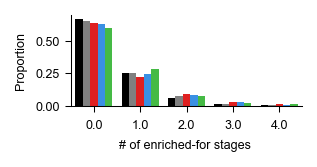

In [97]:


##plot the distribution of values + WT CLNZ
fig, ax = plt.subplots(1,1, figsize = (2,1), layout = 'constrained')
sns.barplot(prop_of_cells_enrich_n_stages, x = 'num_enrich',  y = 'prop_enrich',  **format_no_eb_w_WT_CLNZ) ## tune params
set_ax_title_xlabel_ylabel(ax, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion", 'legend_false': True, 'xlabel': "# of enriched-for stages "})
make_legend = False
if make_legend:
    hand, labs = ax.get_legend_handles_labels() #pull legend from final PCA object and delete it
    fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 5, frameon = True, title = 'Genotype-treatment', **legend_defaults)
#save figure
fig_prefix = "supplement_enrich_" #for sorting in folder
fig_name = "Distrib of stage enrichment count by geno-day + WT_CLNZ"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png'])

#### Supplement 1H: Cell enrichment plots (including WT CLNZ % enriched by stage)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


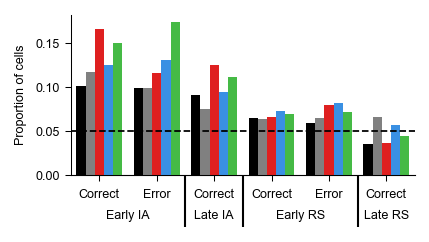

In [98]:
## plot distib of # enriched units by phase
fig, ax_prop_enrich = plt.subplots(1,1, figsize = (2.75,1.5), layout = 'constrained')
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich, order = phase_list_IA_RS_chrono, x = 'phase', y = '% enriched',  **geno_color_dict_w_WT_CLNZ)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None],'legend_false':True,  'ylabel':  f"Proportion of cells", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'
## given ordering of xposition, get the list of what ticks are belonging to what task stage
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono)
#####save fig
fig_prefix = "supplement_enrich_" #for sorting in folder
fig_name =  "% cell stage-enriched barplot_with_WT_CLNZ"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png'])

#### Supplementary Figure 1I- WT CLNZ tSNE projection

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


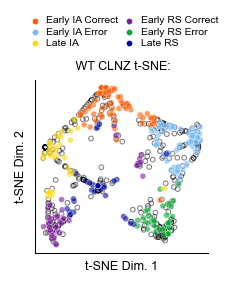

In [99]:
tsne_figsize = (1.5,1.5)
fig,ax =plt.subplots(1,1,figsize = tsne_figsize, layout = 'constrained')
transform = f"t-SNE"
## make plot
geno = 'WT CLNZ'
plot_params = dict( x = 'dim_1', y = 'dim_2',hue = 'ensemble',ax = ax) #constant across both scatters
#plot nonenriched
non_ensemble_df =  tsne_results[geno].loc[tsne_results[geno].ensemble == 'none',:]
sns.scatterplot(**plot_params, data =non_ensemble_df,   s = 5,alpha = 0.5, linewidth =0.5, legend = False, palette = ['black'],  zorder=-1000)
#find collections with > 1 point contained therein
nonlegend_collections = [x for x in ax.collections if x.get_facecolors().shape[0]>1]
collection_size= [x.get_facecolors().shape for x in nonlegend_collections]
largest_collection_size = np.max(collection_size) #use largest collection as == ensemble 
non_enrich_collection = [x for x in nonlegend_collections if x.get_facecolors().shape[0] == largest_collection_size][0]
non_enrich_collection.set_edgecolors(non_enrich_collection.get_facecolors().copy())# Restore the edge colors using the saved values
non_enrich_collection.set_facecolors("none")# Remove the face color by setting it to "none"
#plot ensemble
ensemble_df = tsne_results[geno].loc[tsne_results[geno].ensemble.isin(stage_chrono_order),:]
sns.scatterplot(**plot_params, data =ensemble_df, s = 8,alpha = 0.6, legend = True, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
set_ax_title_xlabel_ylabel(ax,{'title': f" {geno} {transform}:",'ylabel': f'{transform} Dim. 2', 'xlabel': f'{transform} Dim. 1', 'xticks':[], 'yticks':[]})
#get legend and move
hand, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(hand, [x.replace('_', ' ') for x in labels], bbox_to_anchor=(0.5, 1),loc = 'lower center', ncol = 2, frameon = False, title = None, handletextpad=0.1, )
#save fig 
ax.set_box_aspect(1)
fig_name =  f"WT CLNZ TSNE- stage activity matrix"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png'])

#### Supplement Figure 1J- plot % ensemble v nonensemble cells active on each trial

In [100]:
trial_tseries_df_norm.columns

Index(['task_phase_vec', 'IA_RS_vec', 'corr_err_vec', 'trial_num', 'neuron_ID',
       'section', 'subject_name', 'session', 'raw_ID', 'day',
       ...
       'pvalue_post_outcome_Late_RS', 'Run_end_time', 'num_shuffles',
       'any_enrichment', 'enriched_in_phase', 'normalized',
       'max_trial_val_all_time', 'min_max_type', 'mean_rate_in_trial',
       'cell_is_active_in_trial'],
      dtype='object', length=105)

Saved 2_s_Mean % of cells active in stage that are in stage ensemble_posthoc MWU_25_Feb_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_Mean % of cells active in stage that are in stage ensemble_posthoc_text_25_Feb_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


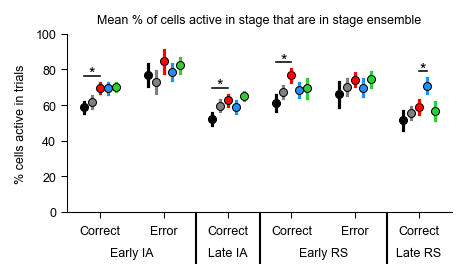

In [101]:
prop_cell_active_in_trial = trial_tseries_df_norm.groupby(by = [subject_col, 'geno_day', 'trial_num', 'task_phase_vec', 'enriched_in_phase'])[['cell_is_active_in_trial']].mean().reset_index() #active in trial is, cell I is active in trial N
## plot % fo cells active by each ensemble embership
fig,plot_ax = plt.subplots(1,1,figsize = (3,1.75), layout = 'constrained')
e_stat_str = {True:'enriched', False: 'non-enriched'}
e_stat = 1.0
plot_mask = prop_cell_active_in_trial.enriched_in_phase == e_stat
#make plot 
plot_df = prop_cell_active_in_trial.loc[plot_mask,:].copy()
plot_df['cell_is_active_in_trial'] = plot_df['cell_is_active_in_trial']*100

plot_params =  {'data': plot_df,  'x':'task_phase_vec', 'y':'cell_is_active_in_trial','orient':'v',
                 'order':stage_chrono_order, 'dodge': 0.5, **geno_order_w_WT_CLNZ_no_eb}
sc = sns.pointplot(ax = plot_ax, linestyles = 'none', **plot_params, errorbar = 'se')
ax_title = f"Mean % of cells active in stage that are in stage ensemble"
set_ax_title_xlabel_ylabel(plot_ax, {'title':ax_title,
                                     'ylabel':  '% cells active in trials', 
                                     'xlabel': None,
                                     'ylim': [0, 100],
                                     'legend_false': True})
posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(plot_ax, plot_params, sc, comparison_list_w_WT_CLNZ,test_name = 'MWU',detect_error_bar=True)
plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
### ANNOTATOR BLOCK END
ax_add_stage_names_and_outline_points(plot_ax)
posthoc_df['plot_name'] = ax_title
#save csv
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="2_s",ax_title,csv_folder_most_recent, None, csv_suffix="posthoc MWU",txt_suffix="posthoc_text")
fig_name = f"supp_Prop stage-active cell in stage ensemble" 
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png','svg'])

## Figure 2 plots

#### Figure 2E- matrix of cell mean activity by task stage (dropping cells with no Early IA Error trials)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


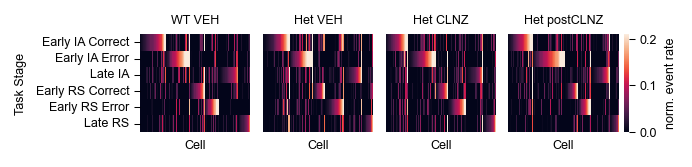

In [102]:
#plot unit heatmap for ALL GENOS
fig_mean_activity, axes = plt.subplots(1,4,figsize = (4.5,1), layout = 'constrained')
heatmap_clabel =  f"norm. event rate"
for count, geno in enumerate(geno_order):
    plot_mask = (AV_matrix.geno_day == geno) & has_Early_IA_Error
    plot_data = AV_matrix.sort_values(by = ['max_phase','max_phase_val'],ascending = True).loc[plot_mask, stage_chrono_order].T
    plot_heatmap_w_kwargs(data =plot_data.rename(index = {p:p.replace('_', ' ') for p in plot_data.index}), ax =axes.flat[count],
                          kwarg_dict = { 'vmin': min_5th_quantile, 'vmax':max_95th_quantile, 'cbar_kws': {'label': heatmap_clabel},
                              'cbar': {True: True, False: False}[count == len(geno_order)-1], 'yticklabels': True, 'xticklabels':False},
                          label_dict = {'xlabel': f"Cell", 'ylabel': {False:"Task Stage", True: None}[count > 0], 'title': geno})
    axes.flat[count].set_yticks({True:[], False: axes.flat[count].get_yticks()}[count > 0])
#save figs
fig_name = 'one_row_cell stage-activity sorted heatmap'
# fig_mean_activity.get_axes()
save_fig_in_main_fig_dir(fig_mean_activity, fig_name= fig_name, folder_key=2, filetypes_to_save = ['png'])

#### Figure 2 H- TSNE projection of (mean stage activity) x (cell_ID) with Ensemble

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


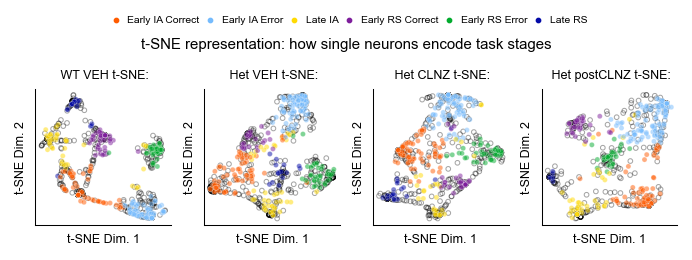

In [103]:
tsne_figsize = (4.5,1.5)
fig,ax_array =plt.subplots(1,4,figsize = tsne_figsize, layout = 'constrained')
transform = f"t-SNE"
fig.suptitle(f"t-SNE representation: how single neurons encode task stages")
## make plot
for geno_count, geno in enumerate(geno_order):#iterate through AVs to project TSNE
    ax = ax_array.flat[geno_count]
    plot_params = dict( x = 'dim_1', y = 'dim_2',hue = 'ensemble',ax = ax) #constant across both scatters
    #plot nonenriched
    non_ens_ax = ax_array.flat[geno_count]
    non_ensemble_df =  tsne_results[geno].loc[tsne_results[geno].ensemble == 'none',:]
    sns.scatterplot(**plot_params, data =non_ensemble_df,   s = 5,alpha = 0.35, linewidth =0.5, legend = False, palette = ['black'],  zorder=0)
    #find collections with > 1 point contained therein
    nonlegend_collections = [x for x in non_ens_ax.collections if x.get_facecolors().shape[0]>1]
    collection_size= [x.get_facecolors().shape for x in nonlegend_collections]
    largest_collection_size = np.max(collection_size) #use largest collection as == ensemble 
    non_enrich_collection = [x for x in nonlegend_collections if x.get_facecolors().shape[0] == largest_collection_size][0]
    non_enrich_collection.set_edgecolors(non_enrich_collection.get_facecolors().copy())# Restore the edge colors using the saved values
    non_enrich_collection.set_facecolors("none")# Remove the face color by setting it to "none"
    make_legend = geno_count == len(geno_order)-1
    
    #plot ensemble
    ensemble_df = tsne_results[geno].loc[tsne_results[geno].ensemble.isin(stage_chrono_order),:]
    sns.scatterplot(**plot_params, data =ensemble_df, s = 6,alpha = 0.5, legend = make_legend, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
    set_ax_title_xlabel_ylabel(ax,{'title': f" {geno} {transform}:",'ylabel': f'{transform} Dim. 2', 'xlabel': f'{transform} Dim. 1', 'xticks':[], 'yticks':[]})
    
#get legend and move
hand, labels = ax_array.flat[-1].get_legend_handles_labels()
ax_array.flat[-1].get_legend().remove()
fig.legend(hand, [x.replace('_', ' ') for x in labels], bbox_to_anchor=(0.5, 1),loc = 'lower center', ncol = 7, frameon = False, title = None, handletextpad=0.1, )
#save fig 
for ax in ax_array.flat:# force each subplot’s BOX to be square:
    ax.set_box_aspect(1)
fig_name =  f"all summary TSNE- {transform} ens mean act in task stage"

save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=2, filetypes_to_save = ['png'])

#### Figure 2F & G- % of cells enriched for each stage, and # of stages enriched for


In [104]:
unique_ID_enrichment_df = unit_mean_tseries.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich = unique_ID_enrichment_df.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = r'% enriched')
geno_mean_enrich.head()

,geno_day,phase,% enriched
0,Het CLNZ,Early_IA_Correct,0.125866
1,Het VEH,Early_IA_Correct,0.165904
2,Het postCLNZ,Early_IA_Correct,0.150480
3,WT CLNZ,Early_IA_Correct,0.117763
4,WT VEH,Early_IA_Correct,0.100926


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


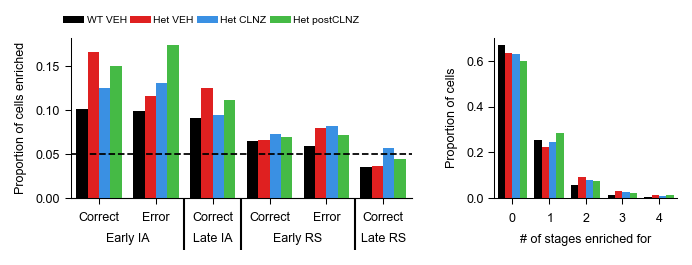

In [105]:

fig, axes = plt.subplots(1,2, figsize = (4.5,1.5), layout = 'constrained', width_ratios = [0.65, 0.35], gridspec_kw = dict(wspace = 0.1))

## plot distib of # enriched units by phase
ax_prop_enrich = axes[0]
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich, x = 'phase', y = '% enriched',order = phase_list_IA_RS_chrono, **geno_color_dict)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono) ## given ordering of xposition, get the list of what ticks are belonging to what task stage
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None], 'legend_false':True, 'ylabel':  f"Proportion of cells enriched", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'

##plot the distribution of values
ax_barplot = axes[1]
sns.barplot(ax = ax_barplot, data= prop_of_cells_enrich_n_stages, x = 'num_enrich',  y = 'prop_enrich',  **geno_color_dict_no_errorbar) ## tune params
set_ax_title_xlabel_ylabel(ax_barplot, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion of cells", 'legend_false':True,'xlabel': "# of stages enriched for"})
ax_barplot.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))
hand, labs = ax_barplot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.3, 1.0),loc = 'lower center', ncols =4, frameon = False, title =None, **legend_defaults)

#####save fig
fig_name =  r"Figure 2F & G- # enriched stage & % enriched by stage_ barplot"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=2, filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

In [106]:
##IA only enriched 
# make sum of cells enriched in IA stages vs RS stages
sum_enrich_in_geno = unique_ID_enrichment_df.reset_index(level=0).groupby(by = 'geno_day').sum()
sum_enrich_in_geno['IA_total'] = sum_enrich_in_geno['Early_IA_Correct']+  sum_enrich_in_geno['Early_IA_Error'] +  sum_enrich_in_geno['Late_IA']
sum_enrich_in_geno['RS_total'] =sum_enrich_in_geno['Early_RS_Correct']+  sum_enrich_in_geno['Early_RS_Error'] +sum_enrich_in_geno['Late_RS']
sum_enrich_in_geno

,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,IA_total,RS_total
geno_day,,,,,,,,
Het CLNZ,109,97.0,63,71,82,49,288.0,183
Het VEH,145,87.0,58,70,110,32,342.0,160
Het postCLNZ,141,120.0,65,67,105,42,366.0,174
WT CLNZ,120,83.0,65,66,77,67,280.0,198
WT VEH,109,86.0,70,64,99,38,294.0,172


## Tabulate/plot ensembles member overlap

In [107]:
from matplotlib_venn import venn2
use_custom_venn_colors = True

In [108]:
def get_geno_stage_overlap_crosstab(input_df, ensemble_to_plot,geno_order,stage_names):
    ''' To- given a set of genotypes to iterate over, anda  dataframe with boolean (ON or OFF) in stage of interests, find the crosstabulation''' 
    set1, set2 = ensemble_to_plot        ## determine # of cells enriched in stage 1 and stage 2, and only either
    output_list = []
    for g, geno in enumerate(geno_order):
        geno_enrich_matrix = input_df.loc[input_df.geno_day==geno, :].groupby(unit_ID_col)[stage_names].first()
        overlap_vec = (geno_enrich_matrix[set1]==1) & (geno_enrich_matrix[set2] ==1)
        total_overlap =  overlap_vec.sum()
        set1_only_size = geno_enrich_matrix[set1].sum().astype(int) - total_overlap
        set2_only_size = geno_enrich_matrix[set2].sum().astype(int) - total_overlap
        output = dict(geno_day = geno,
                      set_1_name = set1,
                      set_2_name = set2, 
                      total_overlap = total_overlap, 
                      n_total = overlap_vec.size,
                      fraction_total_overlap = total_overlap/overlap_vec.size,
                      percent_total_overlap=100* (total_overlap/overlap_vec.size),
                      n_only_in_set_1 = set1_only_size,
                      n_only_in_set_2=set2_only_size, )
        output_list.append(output)
    geno_crosstab= pd.DataFrame.from_records(output_list)
    return geno_crosstab

def plot_ensemble_venn(ax_array, 
                       input_df,
                         ensemble_to_plot,
                         geno_order,
                           stage_names,
                             set_colors = ("r", "g"),
                              label_text_align:dict = {} ):
    set1, set2 = ensemble_to_plot
    venn_objs = dict()
    ## determine # of cells enriched in stage 1 and stage 2, and only either
    geno_crosstab = get_geno_stage_overlap_crosstab(input_df, ensemble_to_plot,geno_order,stage_names)

    for g, geno in enumerate(geno_order): #iterate over axes
        ax = ax_array.flat[g]
        #query pre-existing geno overlap table 
        geno_subset = geno_crosstab.loc[geno_crosstab.geno_day == geno,:]
        set1_size=geno_subset.n_only_in_set_1.values[0]
        set2_size=geno_subset.n_only_in_set_2.values[0]
        total_overlap = geno_subset.total_overlap.values[0]
        venn_objs[geno] = venn2(ax = ax, subsets = (set1_size,set2_size,total_overlap), set_colors = set_colors,
              set_labels = (replace_first_underscore_linebreak(set1), replace_first_underscore_linebreak(set2)))
        for lbl in venn_objs[geno].set_labels:
            lbl.set_fontsize(6)
        venn_title =  f"{geno}:"
        set_labels(ax, {'title':venn_title,})
    
    #new- 12/16/25- move alignment into plot_ensemble_venn()
    for v in venn_objs.values():
        [v.set_labels[k].set_horizontalalignment(val) for k,val in label_text_align.items()] #equiv to: # labels[0].set_horizontalalignment('right') # labels[1].set_horizontalalignment('center')

    return venn_objs



#sub func
def replace_first_underscore_linebreak(input_string):
    ''' Requires N underscores with semantically meaningful breakpoint within it. Takes 1st underscore and swaps with \n'''
    pre_linebreak = input_string.split("_")[0] + "\n" 
    post_linebreak = " ".join(input_string.split("_")[1:])
    return pre_linebreak + post_linebreak

def plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = {0: 'right', 1: 'center'}, 
                                   hspace = (1.5/1.5)*0.75,
                                   wspace = 0.01,
                                   fig_num = 5,
                                   **kwargs):
    
    fig, ax_array = plt.subplots(2,2,figsize =venn_fig_size, 
                                 layout = 'tight', 
                                 gridspec_kw = {'wspace':wspace,'hspace':hspace}) #(1.5/venn_fig_size[1]) is because 0.75 works for 1.5, so below that, increase spacing, and above that, decrease
    ## main venn plot info 
    set_colors = {True: tuple(stage_palette_dict[x] for x in ensemble_to_plot), False: ('r', 'g')}[use_custom_venn_colors]
    venn_objs = plot_ensemble_venn(ax_array, unit_mean_tseries, ensemble_to_plot, geno_order, stage_names,set_colors = set_colors, label_text_align = label_text_align)
    # for v in venn_objs.values():
    #     [v.set_labels[k].set_horizontalalignment(val) for k,val in label_text_align.items()] #equiv to: # labels[0].set_horizontalalignment('right') # labels[1].set_horizontalalignment('center')
    # ##save overlap fig
    fig_name = f"Ensemble cell overlap by geno for {'_'.join(ensemble_to_plot)}"
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png'])
    return fig, ax_array

In [109]:
overlap_tab = []
all_ensemble_pairs =  [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Late_IA'], ['Late_IA','Early_RS_Correct']]
for ensemble_to_plot in all_ensemble_pairs:
    overlap = get_geno_stage_overlap_crosstab(unit_mean_tseries, ensemble_to_plot,geno_order_w_WT_CLNZ,stage_names)
    overlap['contingency'] = overlap.apply(lambda x: np.array([[(x.n_total-x.n_only_in_set_1-x.n_only_in_set_2-x.total_overlap), x.n_only_in_set_1], [x.n_only_in_set_2,x.total_overlap]]),axis = 1)
    #contingency table: [total - only_1 - only_2 - both_1_2], only_1], [only_2, both_1_2] # resChi2ContingencyResult-    An object containing attributes:
    # statistic-float- The test statistic. # pvalue-float The p-value of the test. # dof-int: The degrees of freedom. NaN if method is not None. # expected_freq-ndarray, same shape as observed
    overlap[['statistic', 'pvalue', 'dof', 'expected_frequency']] = overlap.apply(lambda x: chi2_contingency(x.contingency), axis=1, result_type='expand').values
    overlap_tab.append(overlap)
overlap_tab = pd.concat(overlap_tab)
overlap_tab

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Early_IA_Correct,Early_RS_Correct,13,1080,0.012037,1.203704,96,57,"[[914, 96], [57, 13]]",4.973187,0.025743,1,"[[908.0648148148148, 101.93518518518519], [62...."
1,WT CLNZ,Early_IA_Correct,Early_RS_Correct,6,1019,0.005888,0.588813,114,59,"[[840, 114], [59, 6]]",0.210841,0.646109,1,"[[841.6545632973504, 112.34543670264965], [57...."
2,Het VEH,Early_IA_Correct,Early_RS_Correct,33,874,0.037757,3.775744,112,25,"[[704, 112], [25, 33]]",69.845844,0.0,1,"[[680.6224256292907, 135.37757437070937], [48...."
3,Het CLNZ,Early_IA_Correct,Early_RS_Correct,16,866,0.018476,1.847575,93,47,"[[710, 93], [47, 16]]",8.91697,0.002825,1,"[[701.9295612009238, 101.07043879907621], [55...."
4,Het postCLNZ,Early_IA_Correct,Early_RS_Correct,22,937,0.023479,2.347919,119,43,"[[753, 119], [43, 22]]",17.759135,0.000025,1,"[[740.7812166488794, 131.2187833511206], [55.2..."
0,WT VEH,Early_IA_Error,Early_RS_Error,6,1080,0.005556,0.555556,80,58,"[[936, 80], [58, 6]]",0.036935,0.847597,1,"[[935.0962962962963, 80.9037037037037], [58.90..."
1,WT CLNZ,Early_IA_Error,Early_RS_Error,10,1019,0.009814,0.981354,73,56,"[[880, 73], [56, 10]]",3.682976,0.054971,1,"[[875.3758586849852, 77.62414131501473], [60.6..."
2,Het VEH,Early_IA_Error,Early_RS_Error,11,874,0.012586,1.258581,76,59,"[[728, 76], [59, 11]]",2.161407,0.141515,1,"[[723.9679633867277, 80.03203661327231], [63.0..."
3,Het CLNZ,Early_IA_Error,Early_RS_Error,10,866,0.011547,1.154734,87,61,"[[708, 87], [61, 10]]",0.369321,0.543375,1,"[[705.9526558891455, 89.04734411085451], [63.0..."
4,Het postCLNZ,Early_IA_Error,Early_RS_Error,11,937,0.011740,1.173959,109,56,"[[761, 109], [56, 11]]",0.530351,0.466459,1,"[[758.5805763073639, 111.41942369263607], [58...."


#### Supplementary Figure 2A- WT CLNZ inclusive ensemble overlap

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  Min-max normalize a vector, optionally keeping the minimum values unchanged.
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes

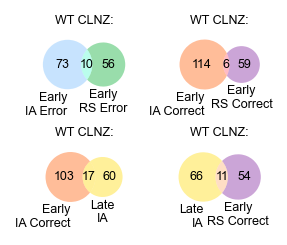

In [110]:
supplement_tag = "supp_"
stage_pairs_WT_CLNZ = [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Correct', 'Late_IA'], ['Late_IA','Early_RS_Correct']]
venn_fig_size = (2.1,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
## make plot 
hspace = (1.5/venn_fig_size[1])*0.85
wspace = .25
fig, ax_array = plt.subplots(2,2,figsize =venn_fig_size, layout = 'tight', gridspec_kw = {'wspace':wspace,'hspace':hspace}) #(1.5/venn_fig_size[1]) is because 0.75 works for 1.5, so below that, increase spacing, and above that, decrease
for p, ensemble_to_plot in enumerate(stage_pairs_WT_CLNZ):    ## main venn plot info 
    set_colors = {True: tuple(stage_palette_dict[x] for x in ensemble_to_plot),False: ('r', 'g')}[use_custom_venn_colors]
    venn_objs = plot_ensemble_venn(np.array(ax_array.flat[p]), unit_mean_tseries,ensemble_to_plot,['WT CLNZ'], stage_names, set_colors = set_colors, label_text_align= label_text_align)
    
fig_name = supplement_tag + f" WT CLNZ Ensemble overlap - all pairs"
fig_num = 's_2'
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png'])

#### Supplementary Figure 2B- get all ensemble membership overlap including WT CLNZ

In [111]:
def make_premade_comparison_pvalue_df(group_list:list, pvalue_list:list):
    ''' To, given a known pvalue for a comparison, bundle and overwrite values '''
    ## zip values together into dict
    comparison_pval_df = pd.DataFrame([dict(group_1= e[0], group_2 = e[1], pvalue=p) for e,p in zip(group_list, pvalue_list)])
    return comparison_pval_df

def update_posthoc_pvalues(posthoc_df:pd.DataFrame, comparison_pvalues:pd.DataFrame):
    #shift index to multiindex of (group1, group2) to streamline accessing
    post = posthoc_df.set_index(["group_1","group_2"])
    cmp  = comparison_pvalues.set_index(["group_1","group_2"])["pvalue"]
    post["pvalue"].update(cmp)
    #overwrite with updated values
    updated_posthoc = posthoc_df
    updated_posthoc["pvalue"] = post["pvalue"].values
    return updated_posthoc

Saved 2_s_Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chisquared_25_Feb_2026.csv to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chi test_25_Feb_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


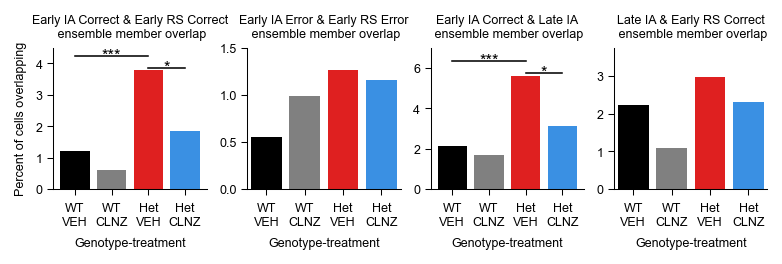

In [112]:
#decide genoplot to amke 
geno_to_plot = ["WT VEH", "WT CLNZ", "Het VEH", "Het CLNZ"]
compare_HET_v_CLNZ_in_WT_VEH= [("WT VEH", "WT CLNZ"), ("Het VEH", "Het CLNZ"), ("WT VEH", "Het VEH")]
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
fig,ax_array = plt.subplots(1,len(all_ensemble_pairs), figsize = (5.1,1.65), layout = 'constrained')
posthoc_df_list = []
ylim_list = [4.5,1.5, 7, 3.75]
## iterate over all wt clnz comparisons
for e, ensemble_to_plot in enumerate(all_ensemble_pairs):
    ax= ax_array.flat[e]
    comparison_mask = (overlap_tab.set_1_name == ensemble_to_plot[0]).values & (overlap_tab.set_2_name == ensemble_to_plot[1]).values
    ensemble_df = overlap_tab.loc[comparison_mask,:]
    plot_df = ensemble_df.loc[ensemble_df.geno_day.isin(geno_to_plot),:]
    plot_params = dict( data =plot_df, x = 'geno_day',y = 'percent_total_overlap',dodge = False,  hue = 'geno_day', hue_order = geno_to_plot, order = geno_to_plot, palette = color_list_WT_CLNZ)
    
    sc= sns.barplot(ax=ax,**plot_params)
    ax_title= f"{' & '.join([x.replace('_', ' ') for x in ensemble_to_plot])}\n ensemble member overlap"
    ylabel = {True:  "Percent of cells overlapping", False: None}
    set_labels(ax, label_dict = dict(title = ax_title, xlabel= "Genotype-treatment", ylabel = ylabel[e ==0], ylim = [0,ylim_list[e]],  legend_false = True))
    
    ##posthoc annot  
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, sc, compare_HET_v_CLNZ_in_WT_VEH,test_name = 'none',ax_var_is_hue = True,
                                                               detect_error_bar=False,plot_type= 'barplot') # plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
    chi_res = [chi2_contingency(plot_df.set_index('geno_day').loc[group,['total_overlap', 'n_total']]) for group in compare_HET_v_CLNZ_in_WT_VEH]
    ## combine into new format
    real_pvalues  = make_premade_comparison_pvalue_df(compare_HET_v_CLNZ_in_WT_VEH, [x.pvalue for x in chi_res])
    posthoc_df= update_posthoc_pvalues(posthoc_df, comparison_pvalues = real_pvalues)    ## make table with precomputed comparison p-value for overwrite  
    posthoc_df.loc[:,'category_compared_within'] = "_x_".join(ensemble_to_plot)
    posthoc_df.stat_result  = [[x.statistic, x.pvalue] for x in chi_res]
    posthoc_df.loc[:,'test_name'] = "chi_squared"
    posthoc_df_list.append(posthoc_df)
    plot_sig_bars_w_comp_df_tight(ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:],tight_offset = 0.02,offset_constant=0.015)
    ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
## save it
posthoc_df = pd.concat(posthoc_df_list)
fig_name = f"Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="2_s",fig_name,  csv_folder_most_recent, None, csv_suffix="ensemble chisquared",txt_suffix="ensemble chi test")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)

#### Figure 5A- Early IA/RS Error Ens overlap 

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\25_Feb_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  Min-max normalize a vector, optionally keeping the minimum values unchanged.
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes

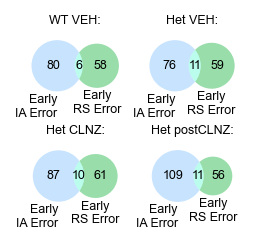

In [113]:
ensemble_to_plot = ['Early_IA_Error', 'Early_RS_Error']
venn_fig_size = (2.,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = {0: 'right', 1: 'center'}, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                   fig_num = 5)

In [114]:
def plot_ensemble_percent_overlap(unit_mean_tseries, 
                                  ensemble_to_plot,
                                  stage_names,
                                  geno_order,
                                  color_list,
                                  add_sig_bars=False,
                                  add_legend = False,
                                  sig_ensemble_overlap=[], 
                                  ensemble_pvalue=[],
                                  ylim = None,
                                  test_name = "none"):
    #make plot 
    if ylim != None:
        ax.set_ylim(ylim)

    geno_crosstab = get_geno_stage_overlap_crosstab(unit_mean_tseries, ensemble_to_plot,geno_order,stage_names)##now extract and plot comparison of % overlap ensemble     
    plot_params = dict( data = geno_crosstab, x = 'geno_day',y = 'percent_total_overlap',dodge = False,  hue = 'geno_day', hue_order = geno_order, order = geno_order, palette = color_list)
    sc= sns.barplot(ax=ax,**plot_params)
    ax_title= f"{' & '.join([x.replace('_', ' ') for x in ensemble_to_plot])}\n ensemble membership overlap"
    set_labels(ax, label_dict = dict(title = ax_title, xlabel= "Genotype-treatment", ylabel = "Percent of cells overlapping", legend_false = True))
    posthoc_df = []
    if add_sig_bars:# get hue loc, overwrite P-value due to external chisquared
        posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, sc, preset_comparison_list,test_name = test_name,detect_error_bar=False,plot_type= 'barplot') # plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
        posthoc_df= update_posthoc_pvalues(posthoc_df, comparison_pvalues = make_premade_comparison_pvalue_df(sig_ensemble_overlap, ensemble_pvalue))    ## make table with precomputed comparison p-value for overwrite
        plot_sig_bars_w_comp_df_tight(ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:],tight_offset = 0.03,offset_constant=0.02)
    
    if add_legend:
        hand, labs =ax.get_legend_handles_labels() #pull legend from final PCA object and delete it
        plt.gcf().legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.05,
            'markerscale': 0.1,
            'borderpad': 0.0,
            'columnspacing': 0.25,
            'handletextpad': 0.15})
    
    ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
  

    return posthoc_df

In [115]:
member_overlap_figsize = (1.75,1.75)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_5\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


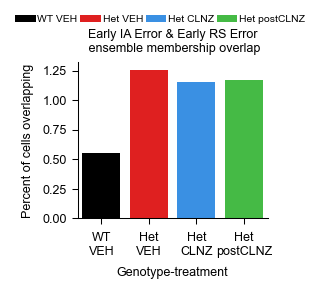

In [116]:
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')
#new- preset pvalue due to external chi-squared calculation
add_sig_bars = False
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
ensemble_pvalue = [1,1]
ensemble_to_plot = ['Early_IA_Error', 'Early_RS_Error']

## main fig logic
#make plot
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,
                                  geno_order,color_list, add_sig_bars,
                                  add_legend = True,
                                  sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue)
##save fig 
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=5, filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)

#### Figure 6A- Early IA/RS Correct ens overlap 

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\25_Feb_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  Min-max normalize a vector, optionally keeping the minimum values unchanged.
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes

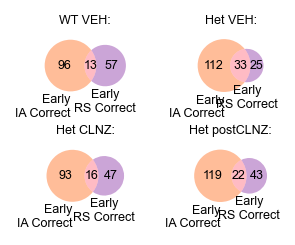

In [117]:
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
venn_fig_size = (2.5,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
hspace = (1.5/venn_fig_size[1])*0.75

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = {0: 'right', 1: 'center'}, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                    wspace = 0,
                                   fig_num = 6)

('xkcd:bright orange', 'xkcd:purple')
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


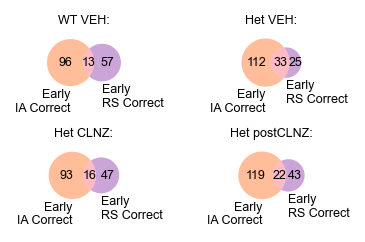

In [118]:
fig, ax_array = plt.subplots(2,2,figsize = venn_fig_size, layout = 'constrained')
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
## main venn plot info 
set_colors = {True: tuple(stage_palette_dict[x] for x in ensemble_to_plot), False: ('r', 'g')}[use_custom_venn_colors]
print(set_colors)
plot_ensemble_venn(ax_array, unit_mean_tseries, ensemble_to_plot, geno_order, stage_names,set_colors = set_colors)
##save overlap fig
fig_name = f"Geno-days- ensemble members- {'_'.join(ensemble_to_plot)} set"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=6, filetypes_to_save = ['png'])

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_6\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


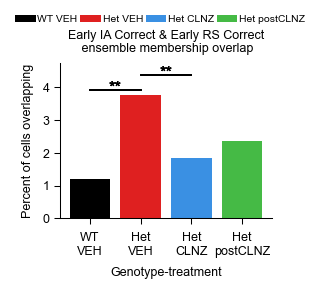

In [119]:
#new- preset pvalue due to external chi-squared calculation
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')

add_sig_bars = True
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ"), ("Het VEH", "Het postCLNZ")]
ensemble_pvalue = [0.0011,0.0045]
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
## main fig logic
# ax.set_ylim([0,4.75])
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,
                                  geno_order,color_list, add_sig_bars, add_legend = True,
                                  sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,4.75] )
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=6, filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)

#### Figure 7A- late IA vs. early IA correct for late IA / late IA vs. early RS correct for early RS correct 

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\25_Feb_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  Min-max normalize a vector, optionally keeping the minimum values unchanged.
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes

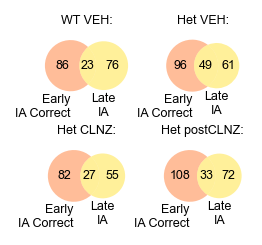

In [120]:
ensemble_to_plot = ['Early_IA_Correct', 'Late_IA']
venn_fig_size = (2.0,1.5)
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
hspace = (1.5/venn_fig_size[1])*0.75

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = {0: 'right', 1: 'center'}, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                    wspace = 0,
                                   fig_num = 7)

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


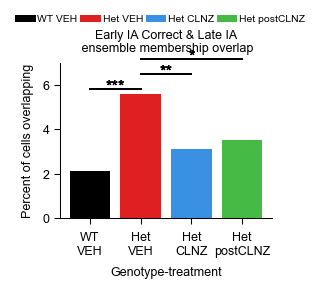

In [121]:
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')

#preset pvalue due to external chi-squared calculation
add_sig_bars = True
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ"), ("Het VEH", "Het postCLNZ")]
ensemble_pvalue = [0.0001,0.004,0.032]
ensemble_to_plot = ['Early_IA_Correct', 'Late_IA']
## main fig logic
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names, geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,7])
##save fig 
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=7, filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)

#### Figure 7E- early RS correct vs. late RS ensemble membership overlap

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  Min-max normalize a vector, optionally keeping the minimum values unchanged.
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes

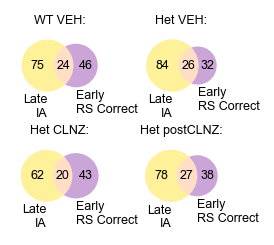

In [122]:
ensemble_to_plot = ['Late_IA','Early_RS_Correct']
venn_fig_size = (2.0,1.5)
label_text_align = {0: 'right', 1: 'left'}  #relationship of label pos to what horz alignment to use
hspace = (1.5/venn_fig_size[1])*0.75

fig, ax_array = plot_save_ensemble_overlap_fig(unit_mean_tseries,
                                   ensemble_to_plot,
                                   geno_order,
                                   stage_names,
                                   venn_fig_size, 
                                   label_text_align = label_text_align, 
                                   hspace = (1.5/venn_fig_size[1])*0.75,
                                    wspace = 0.1,
                                   fig_num = 7)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\25_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


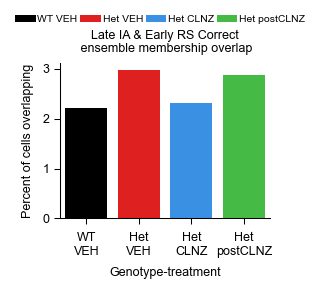

In [123]:
#new- preset pvalue due to external chi-squared calculation
add_sig_bars = True
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
ensemble_pvalue = [0.08,0.15]
ensemble_to_plot = ['Late_IA','Early_RS_Correct']
## main fig logic
fig, ax = plt.subplots(1,1, figsize =member_overlap_figsize,layout= 'constrained')
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue)
##save fig 
fig_name = f"{'_'.join(ensemble_to_plot)} proportion overlap"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=7, filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)

#### Summary Figures:

#### Summary figure- membership overlap

In [124]:
genos_compare_ens_overlap = [("WT VEH", "Het VEH"),
                             ("Het VEH", "Het CLNZ"),
                             ("Het VEH", "Het postCLNZ")]
print(genos_compare_ens_overlap)

overlap_pairs = set([z for z in zip(overlap_tab['set_1_name'], overlap_tab['set_2_name'])])
print(overlap_pairs)

[('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ'), ('Het VEH', 'Het postCLNZ')]
{('Late_IA', 'Early_RS_Correct'), ('Early_IA_Error', 'Early_RS_Error'), ('Early_IA_Correct', 'Early_RS_Correct'), ('Early_IA_Correct', 'Late_IA')}


In [125]:
overlap_store = [] #store in list to concat after
for comp in genos_compare_ens_overlap:
    comp_name = "_vs_".join(comp)
    for ens_pair in overlap_pairs:
        print(comp_name, ens_pair)
        #format geno1 comp
        geno_1_df = overlap_tab[overlap_tab.geno_day== comp[0]]
        geno_1_comp = geno_1_df[(geno_1_df.set_1_name == ens_pair[0]) & (geno_1_df.set_2_name == ens_pair[1])].reset_index()

        #geno 2 comp
        geno_2_df = overlap_tab[overlap_tab.geno_day== comp[1]]
        geno_2_comp =geno_2_df[(geno_2_df.set_1_name == ens_pair[0]) & (geno_2_df.set_2_name == ens_pair[1])].reset_index()

        #get overlap
        cols_to_keep = ['geno_day', 'total_overlap', 'n_total']
        geno_compare_overlap_df = geno_1_comp[['set_1_name', 'set_2_name'] + cols_to_keep].join(geno_2_comp[cols_to_keep], lsuffix= "_geno_1", rsuffix = "_geno_2").assign(geno_comparison = comp_name, ensemble_comparison = "_vs_".join(ens_pair))

        # make contingency table: compare [[g1_overlap, g1_nonoverlap], [g2_overlap, g2_nonoverlap]]
        geno_compare_overlap_df['geno_compare_overlap'] = geno_compare_overlap_df.apply(lambda x: np.array([[x.total_overlap_geno_1, x.n_total_geno_1] , [x.total_overlap_geno_2, x.n_total_geno_2]]),axis = 1)
        geno_compare_overlap_df[['statistic', 'pvalue', 'dof', 'expected_frequency']] = geno_compare_overlap_df.apply(lambda x: chi2_contingency(x.geno_compare_overlap), axis=1, result_type='expand').values
        overlap_store.append(geno_compare_overlap_df)
geno_compare_overlap_df = pd.concat(overlap_store)
geno_compare_overlap_df


WT VEH_vs_Het VEH ('Late_IA', 'Early_RS_Correct')
WT VEH_vs_Het VEH ('Early_IA_Error', 'Early_RS_Error')
WT VEH_vs_Het VEH ('Early_IA_Correct', 'Early_RS_Correct')
WT VEH_vs_Het VEH ('Early_IA_Correct', 'Late_IA')
Het VEH_vs_Het CLNZ ('Late_IA', 'Early_RS_Correct')
Het VEH_vs_Het CLNZ ('Early_IA_Error', 'Early_RS_Error')
Het VEH_vs_Het CLNZ ('Early_IA_Correct', 'Early_RS_Correct')
Het VEH_vs_Het CLNZ ('Early_IA_Correct', 'Late_IA')
Het VEH_vs_Het postCLNZ ('Late_IA', 'Early_RS_Correct')
Het VEH_vs_Het postCLNZ ('Early_IA_Error', 'Early_RS_Error')
Het VEH_vs_Het postCLNZ ('Early_IA_Correct', 'Early_RS_Correct')
Het VEH_vs_Het postCLNZ ('Early_IA_Correct', 'Late_IA')


,set_1_name,set_2_name,geno_day_geno_1,total_overlap_geno_1,n_total_geno_1,geno_day_geno_2,total_overlap_geno_2,n_total_geno_2,geno_comparison,ensemble_comparison,geno_compare_overlap,statistic,pvalue,dof,expected_frequency
0,Late_IA,Early_RS_Correct,WT VEH,24,1080,Het VEH,26,874,WT VEH_vs_Het VEH,Late_IA_vs_Early_RS_Correct,"[[24, 1080], [26, 874]]",0.768663,0.380631,1,"[[27.54491017964072, 1076.4550898203593], [22...."
0,Early_IA_Error,Early_RS_Error,WT VEH,6,1080,Het VEH,11,874,WT VEH_vs_Het VEH,Early_IA_Error_vs_Early_RS_Error,"[[6, 1080], [11, 874]]",1.971123,0.160329,1,"[[9.366818873668189, 1076.633181126332], [7.63..."
0,Early_IA_Correct,Early_RS_Correct,WT VEH,13,1080,Het VEH,33,874,WT VEH_vs_Het VEH,Early_IA_Correct_vs_Early_RS_Correct,"[[13, 1080], [33, 874]]",12.162182,0.000488,1,"[[25.139, 1067.861], [20.861, 886.139]]"
0,Early_IA_Correct,Late_IA,WT VEH,23,1080,Het VEH,49,874,WT VEH_vs_Het VEH,Early_IA_Correct_vs_Late_IA,"[[23, 1080], [49, 874]]",14.308561,0.000155,1,"[[39.19842053307009, 1063.80157946693], [32.80..."
0,Late_IA,Early_RS_Correct,Het VEH,26,874,Het CLNZ,20,866,Het VEH_vs_Het CLNZ,Late_IA_vs_Early_RS_Correct,"[[26, 874], [20, 866]]",0.480317,0.488279,1,"[[23.180291153415453, 876.8197088465845], [22...."
0,Early_IA_Error,Early_RS_Error,Het VEH,11,874,Het CLNZ,10,866,Het VEH_vs_Het CLNZ,Early_IA_Error_vs_Early_RS_Error,"[[11, 874], [10, 866]]",0.0,1.0,1,"[[10.55366269165247, 874.4463373083476], [10.4..."
0,Early_IA_Correct,Early_RS_Correct,Het VEH,33,874,Het CLNZ,16,866,Het VEH_vs_Het CLNZ,Early_IA_Correct_vs_Early_RS_Correct,"[[33, 874], [16, 866]]",4.922646,0.026507,1,"[[24.842370039128003, 882.157629960872], [24.1..."
0,Early_IA_Correct,Late_IA,Het VEH,49,874,Het CLNZ,27,866,Het VEH_vs_Het CLNZ,Early_IA_Correct_vs_Late_IA,"[[49, 874], [27, 866]]",5.35505,0.020662,1,"[[38.62775330396476, 884.3722466960353], [37.3..."
0,Late_IA,Early_RS_Correct,Het VEH,26,874,Het postCLNZ,27,937,Het VEH_vs_Het postCLNZ,Late_IA_vs_Early_RS_Correct,"[[26, 874], [27, 937]]",0.0,1.0,1,"[[25.590128755364805, 874.4098712446352], [27...."
0,Early_IA_Error,Early_RS_Error,Het VEH,11,874,Het postCLNZ,11,937,Het VEH_vs_Het postCLNZ,Early_IA_Error_vs_Early_RS_Error,"[[11, 874], [11, 937]]",0.0,1.0,1,"[[10.621931260229132, 874.3780687397708], [11...."


In [126]:
def get_sig_ensemble_overlap_diff_by_geno(sig_ens_data:pd.DataFrame):
    ''' To use for checking if the geno vs geno overlap comparison has a sig difference, and iterating over the elements if so '''
    add_sig_bars = sig_ens_data.shape[0] > 0
    sig_ensemble_overlap, ensemble_pvalue =[], []
    if add_sig_bars:
        for row in sig_ens_data.itertuples():
            sig_geno_diff = (row.geno_day_geno_1, row.geno_day_geno_2)
            sig_geno_pval = row.pvalue
            #append to lists 
            sig_ensemble_overlap.append(sig_geno_diff)
            ensemble_pvalue.append(sig_geno_pval) #new- preset pvalue due to external chi-squared calculation
    return add_sig_bars, sig_ensemble_overlap, ensemble_pvalue

In [127]:
#given ensemble made, get pvalue and sig overlaps:
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue

(False, [], [])

In [128]:

# index chi2 overlap tabulation, then get those with p < 0.05
curr_venn_contingency = overlap_tab[(overlap_tab.set_1_name == ensemble_to_plot[0]) & (overlap_tab.set_2_name == ensemble_to_plot[1])]
curr_venn_sig_overlap = curr_venn_contingency[curr_venn_contingency.pvalue < 0.05]
curr_venn_sig_overlap.columns

Index(['geno_day', 'set_1_name', 'set_2_name', 'total_overlap', 'n_total',
       'fraction_total_overlap', 'percent_total_overlap', 'n_only_in_set_1',
       'n_only_in_set_2', 'contingency', 'statistic', 'pvalue', 'dof',
       'expected_frequency'],
      dtype='object')

add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = (True, [('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ')], [0.00015515760530983294, 0.020662341733314576])
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = (True, [('WT VEH', 'Het VEH'), ('Het VEH', 'Het CLNZ')], [0.000487683017406148, 0.02650689641195708])
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = (False, [], [])
Saving Figure 5-7 Ensemble Overlap Quantification_25_Feb_2026
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\fig_7\25_Feb_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_obj.savefig((save_loc / date_dir / f"{fig_name}{date_tag}.{fig_type}"), **save_args)


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\25_Feb_2026' already exists.


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\helper_functions.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  Min-max normalize a vector, optionally keeping the minimum values unchanged.
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


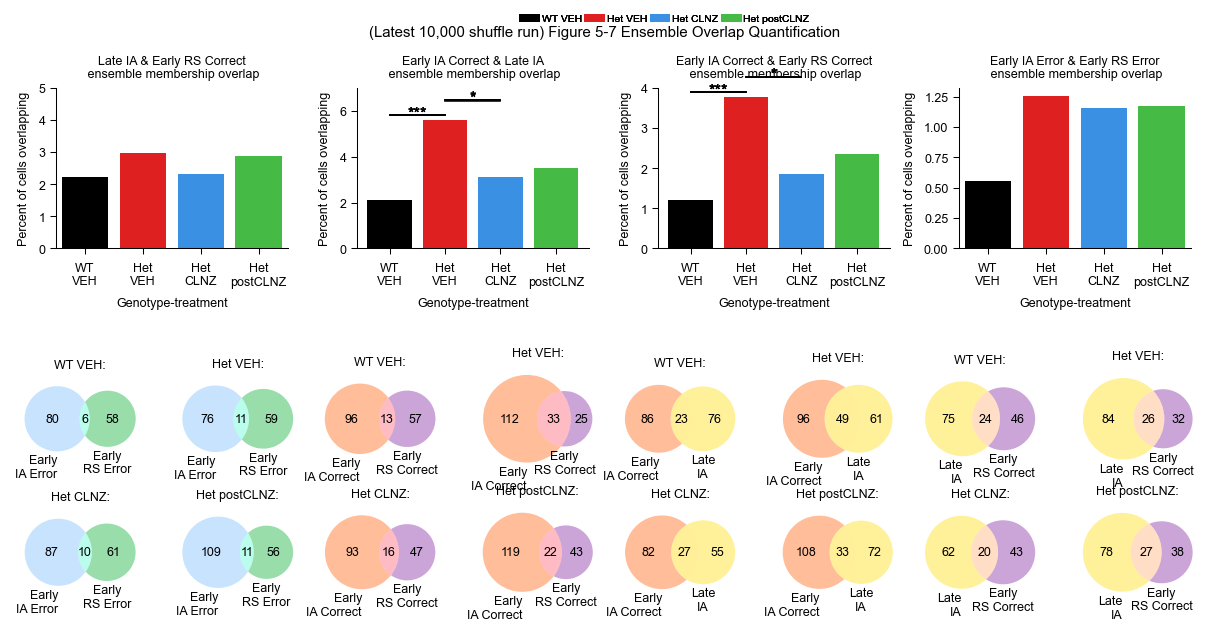

In [129]:
#constant params:
fig = plt.figure(figsize =(8,4),layout= 'tight')
fig.suptitle(f"(Latest 10,000 shuffle run) Figure 5-7 Ensemble Overlap Quantification")
#make subfigs
subfig_array = fig.subfigures(2,1, height_ratios= [0.4,0.6], hspace = 0.2)

#make bar subfig
subfig_n = 0
ax_array_bars = subfig_array[subfig_n].subplots(1,4,)

#plot late IA & Early RS COrrect
ax = ax_array_bars.flat[0]
ensemble_to_plot = ['Late_IA','Early_RS_Correct']
# add_sig_bars = True
# sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
# ensemble_pvalue = [0.08,0.15] #new- preset pvalue due to external chi-squared calculation
#given ensemble made, get pvalue and sig overlaps:
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,5])

#plot early IA Correct vs Late IA
ax = ax_array_bars.flat[1]
ensemble_to_plot = ['Early_IA_Correct', 'Late_IA']
# add_sig_bars = True
# sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ"), ("Het VEH", "Het postCLNZ")]
# ensemble_pvalue = [0.0001,0.004,0.032]
#given ensemble made, get pvalue and sig overlaps:
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
print(f"add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = {add_sig_bars, sig_ensemble_overlap, ensemble_pvalue}")
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names, geno_order,color_list, add_sig_bars,add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,7])

## plot IA vs RS Correct:
ax = ax_array_bars.flat[2]
ensemble_to_plot = ['Early_IA_Correct', 'Early_RS_Correct']
# sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ"), ("Het VEH", "Het postCLNZ")]
# ensemble_pvalue = [0.0011,0.0045]
# add_sig_bars = True #true if ens pvalue < 0.05
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
print(f"add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = {add_sig_bars, sig_ensemble_overlap, ensemble_pvalue}")
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars, add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue, ylim = [0,4])

## plot IA vs RS Error:
ax = ax_array_bars.flat[3]
ensemble_to_plot = ['Early_IA_Error', 'Early_RS_Error']
# add_sig_bars = False
# sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
# ensemble_pvalue = [1,1]
plot_ens_data = geno_compare_overlap_df[(geno_compare_overlap_df.set_1_name == ensemble_to_plot[0]) & (geno_compare_overlap_df.set_2_name == ensemble_to_plot[1])]
add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = get_sig_ensemble_overlap_diff_by_geno(plot_ens_data[plot_ens_data.pvalue < 0.05])
print(f"add_sig_bars, sig_ensemble_overlap, ensemble_pvalue = {add_sig_bars, sig_ensemble_overlap, ensemble_pvalue}")
plot_ensemble_percent_overlap(unit_mean_tseries, ensemble_to_plot,stage_names,geno_order,color_list, add_sig_bars, add_legend = True, sig_ensemble_overlap=sig_ensemble_overlap, ensemble_pvalue= ensemble_pvalue)

#### #make VENN  subfig
subfig_n = 1
subfigs_venn = subfig_array[subfig_n].subfigures(1,4, )
hspace = 0.25
wspace = .25
#all comps:
all_ens_venn = [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Correct', 'Late_IA'],['Late_IA','Early_RS_Correct']]
label_text_align = {0: 'right', 1: 'center'}  #relationship of label pos to what horz alignment to use
## make plot 
for e, ensemble_to_plot in enumerate(all_ens_venn):
    ax_array = subfigs_venn[e].subplots(2,2, gridspec_kw = {'wspace':wspace,'hspace':hspace}) #(1.5/venn_fig_size[1]) is because 0.75 works for 1.5, so below that, increase spacing, and above that, decrease
    venn_objs = plot_ensemble_venn(ax_array, 
                                unit_mean_tseries,
                                    ensemble_to_plot,
                                    geno_order,
                                        stage_names,
                                        set_colors = tuple(stage_palette_dict[x] for x in ensemble_to_plot), 
                                        label_text_align = label_text_align)

fig_name = f"Figure 5-7 Ensemble Overlap Quantification_{date_tag}"
print(f"Saving {fig_name}")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=7, filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)